In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spotify200/final.csv


In [5]:
df = pd.read_csv("/kaggle/input/spotify200/final.csv")

/tmp/ipykernel_36/165273368.py:1: DtypeWarning: Columns (2,4,9,12,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30,31,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/spotify200/final.csv")


In [6]:
df.head()

,Unnamed: 0,uri,rank,artist_names,artists_num,artist_individual,artist_id,artist_genre,artist_img,collab,...,acousticness,instrumentalness,liveness,valence,tempo,duration,country,region,language,pivot
0,0,spotify:track:2gpQi3hbcUAcEG8m2dlgfB,1,Paulo Londra,1.0,Paulo Londra,spotify:artist:3vQ0GE3mI0dAaxIMYe5g7z,argentine hip hop,https://i.scdn.co/image/ab6761610000e5ebf796a9...,0,...,0.0495,0.0,0.0658,0.557,173.935,178203.0,Argentina,South America,Spanish,0
1,1,spotify:track:2x8oBuYaObjqHqgGuIUZ0b,2,WOS,1.0,WOS,spotify:artist:5YCc6xS5Gpj3EkaYGdjyNK,argentine indie,https://i.scdn.co/image/ab6761610000e5eb75e151...,0,...,0.724,0.0,0.134,0.262,81.956,183547.0,Argentina,South America,Spanish,0
2,2,spotify:track:2SJZdZ5DLtlRosJ2xHJJJa,3,Paulo Londra,1.0,Paulo Londra,spotify:artist:3vQ0GE3mI0dAaxIMYe5g7z,argentine hip hop,https://i.scdn.co/image/ab6761610000e5ebf796a9...,0,...,0.241,0.0,0.0929,0.216,137.915,204003.0,Argentina,South America,Spanish,0
3,3,spotify:track:1O2pcBJGej0pmH2Y9XZMs6,5,Cris Mj,1.0,Cris Mj,spotify:artist:1Yj5Xey7kTwvZla8sqdsdE,urbano chileno,https://i.scdn.co/image/ab6761610000e5eb8f4ebc...,0,...,0.0924,0.000046,0.0534,0.832,96.018,153750.0,Argentina,South America,Spanish,0
4,4,spotify:track:1TpZKxGnHp37ohJRszTSiq,6,Emilia,1.0,Emilia,spotify:artist:0AqlFI0tz2DsEoJlKSIiT9,pop argentino,https://i.scdn.co/image/ab6761610000e5ebaf96d1...,0,...,0.0811,0.000063,0.101,0.501,95.066,133895.0,Argentina,South America,Spanish,0


In [7]:
df=df.drop(columns=['Unnamed: 0','uri','artist_names','artist_individual','artist_individual','artist_img','artist_id','track_name','album_cover','source','artist_genre'])

In [8]:
df.head()

,rank,artists_num,collab,release_date,album_num_tracks,peak_rank,previous_rank,weeks_on_chart,streams,week,...,acousticness,instrumentalness,liveness,valence,tempo,duration,country,region,language,pivot
0,1,1.0,0,2022-03-23,1.0,1,1,4,3003411,2022-04-14,...,0.0495,0.0,0.0658,0.557,173.935,178203.0,Argentina,South America,Spanish,0
1,2,1.0,0,2022-04-06,1.0,2,129,2,2512175,2022-04-14,...,0.724,0.0,0.134,0.262,81.956,183547.0,Argentina,South America,Spanish,0
2,3,1.0,0,2022-04-06,2.0,3,59,2,2408983,2022-04-14,...,0.241,0.0,0.0929,0.216,137.915,204003.0,Argentina,South America,Spanish,0
3,5,1.0,0,2022-01-21,1.0,5,5,8,2080139,2022-04-14,...,0.0924,0.000046,0.0534,0.832,96.018,153750.0,Argentina,South America,Spanish,0
4,6,1.0,0,2022-03-24,1.0,6,9,3,1923270,2022-04-14,...,0.0811,0.000063,0.101,0.501,95.066,133895.0,Argentina,South America,Spanish,0


In [9]:
df.columns

Index(['rank', 'artists_num', 'collab', 'release_date', 'album_num_tracks',
       'peak_rank', 'previous_rank', 'weeks_on_chart', 'streams', 'week',
       'danceability', 'energy', 'key', 'mode', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration', 'country', 'region', 'language', 'pivot'],
      dtype='object')

In [10]:
df = df.drop(columns=['week','release_date','country','region','language'])

In [11]:
df.isnull().sum()

rank                  0
artists_num           0
collab                0
album_num_tracks      0
peak_rank             0
previous_rank         0
weeks_on_chart        0
streams               0
danceability        395
energy              395
key                 395
mode                395
loudness            395
speechiness         395
acousticness        395
instrumentalness    395
liveness            395
valence             395
tempo               395
duration            395
pivot                 0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

rank                0
artists_num         0
collab              0
album_num_tracks    0
peak_rank           0
previous_rank       0
weeks_on_chart      0
streams             0
danceability        0
energy              0
key                 0
mode                0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration            0
pivot               0
dtype: int64

In [14]:
for i in df.columns:
    df[i]=pd.to_numeric(df[i],errors='coerce')

In [15]:
df.isnull().sum()

rank                73
artists_num         73
collab              73
album_num_tracks    73
peak_rank           73
previous_rank       73
weeks_on_chart      73
streams             73
danceability        73
energy              73
key                 73
mode                73
loudness            73
speechiness         73
acousticness        73
instrumentalness    73
liveness            73
valence             73
tempo               73
duration            73
pivot               73
dtype: int64

In [16]:
df.dropna(inplace=True)

In [17]:
df.shape

(1787531, 21)

In [18]:
df.head()

,rank,artists_num,collab,album_num_tracks,peak_rank,previous_rank,weeks_on_chart,streams,danceability,energy,...,mode,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,pivot
0,1.0,1.0,0.0,1.0,1.0,1.0,4.0,3003411.0,0.583,0.834,...,1.0,-4.875,0.0444,0.0495,0.000000,0.0658,0.557,173.935,178203.0,0.0
1,2.0,1.0,0.0,1.0,2.0,129.0,2.0,2512175.0,0.654,0.354,...,1.0,-7.358,0.0738,0.7240,0.000000,0.1340,0.262,81.956,183547.0,0.0
2,3.0,1.0,0.0,2.0,3.0,59.0,2.0,2408983.0,0.721,0.463,...,0.0,-9.483,0.0646,0.2410,0.000000,0.0929,0.216,137.915,204003.0,0.0
3,5.0,1.0,0.0,1.0,5.0,5.0,8.0,2080139.0,0.870,0.548,...,0.0,-5.253,0.0770,0.0924,0.000046,0.0534,0.832,96.018,153750.0,0.0
4,6.0,1.0,0.0,1.0,6.0,9.0,3.0,1923270.0,0.761,0.696,...,0.0,-3.817,0.0505,0.0811,0.000063,0.1010,0.501,95.066,133895.0,0.0


In [19]:
df['rank'].value_counts().reset_index()

,rank,count
0,20.0,9435
1,30.0,9421
2,17.0,9416
3,26.0,9409
4,16.0,9408
...,...,...
195,164.0,8577
196,200.0,8576
197,191.0,8575
198,189.0,8511


In [20]:
df= df.sample(50000)

In [21]:
df['rank'].value_counts().reset_index()

,rank,count
0,6.0,300
1,42.0,297
2,30.0,295
3,58.0,289
4,82.0,288
...,...,...
195,149.0,215
196,139.0,215
197,100.0,207
198,168.0,205


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = (12, 6)

/tmp/ipykernel_36/3017126149.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


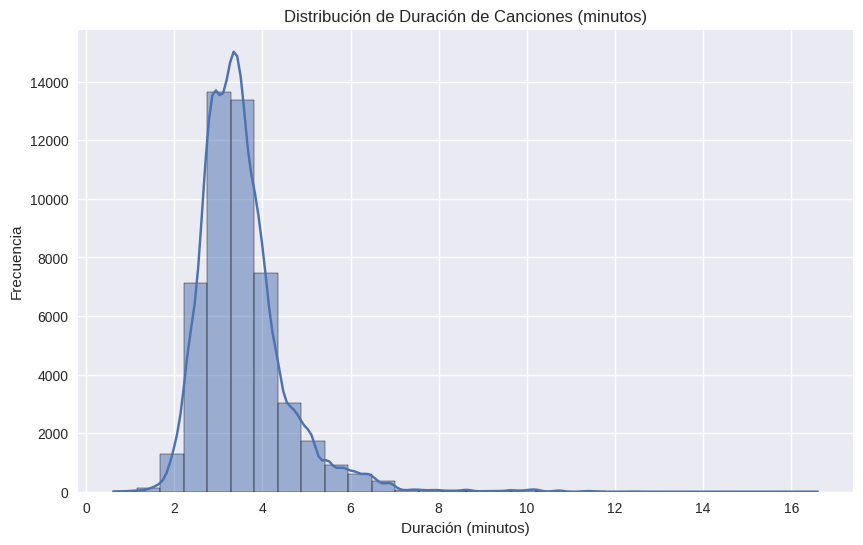

In [23]:

df['duration_min'] = df['duration'] / 60000

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='duration_min', bins=30, kde=True)
plt.title('Distribución de Duración de Canciones (minutos)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')
plt.show()

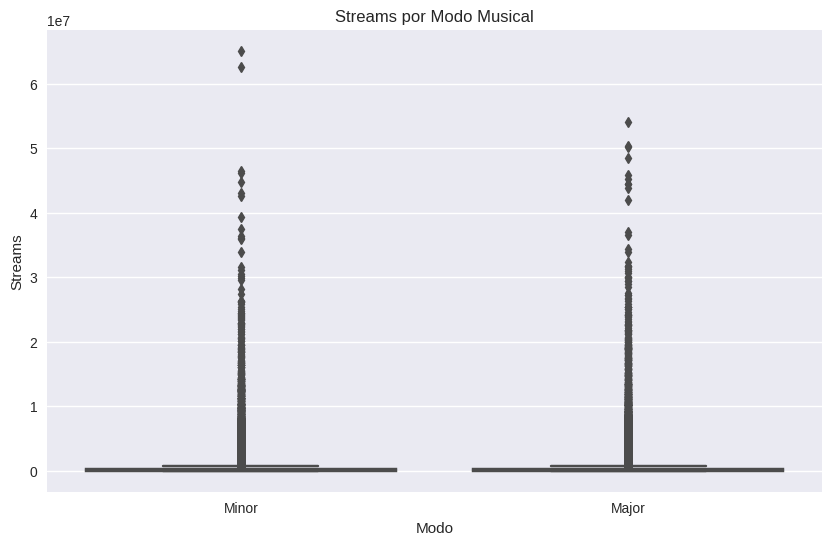

In [24]:

df['mode'] = df['mode'].map({0: 'Minor', 1: 'Major'})

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='mode', y='streams')
plt.title('Streams por Modo Musical')
plt.xlabel('Modo')
plt.ylabel('Streams')
plt.show()

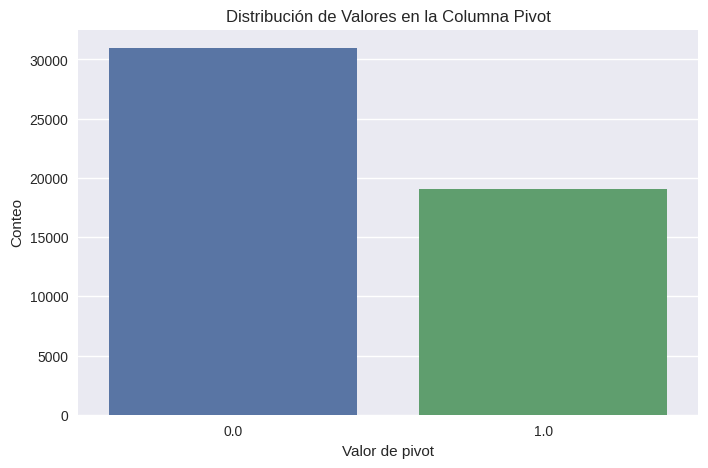

Valores únicos en 'pivot': [0. 1.]
Conteo de valores en 'pivot':
pivot
0.0    30958
1.0    19042
Name: count, dtype: int64


In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pivot')
plt.title('Distribución de Valores en la Columna Pivot')
plt.xlabel('Valor de pivot')
plt.ylabel('Conteo')
plt.show()

print(f"Valores únicos en 'pivot': {df['pivot'].unique()}")
print(f"Conteo de valores en 'pivot':\n{df['pivot'].value_counts()}")

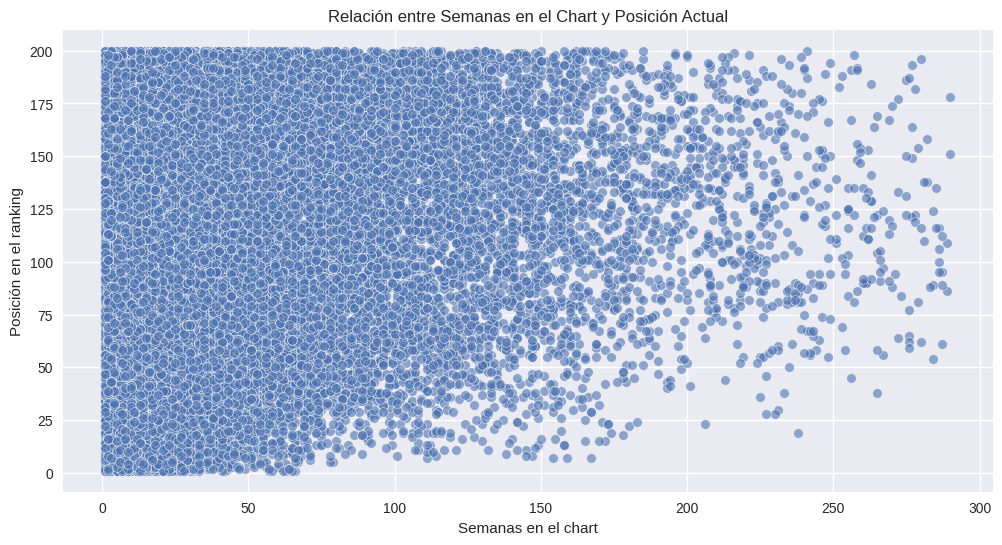

In [26]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='weeks_on_chart', y='rank', alpha=0.6)
plt.title('Relación entre Semanas en el Chart y Posición Actual')
plt.xlabel('Semanas en el chart')
plt.ylabel('Posición en el ranking')
plt.gca()
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


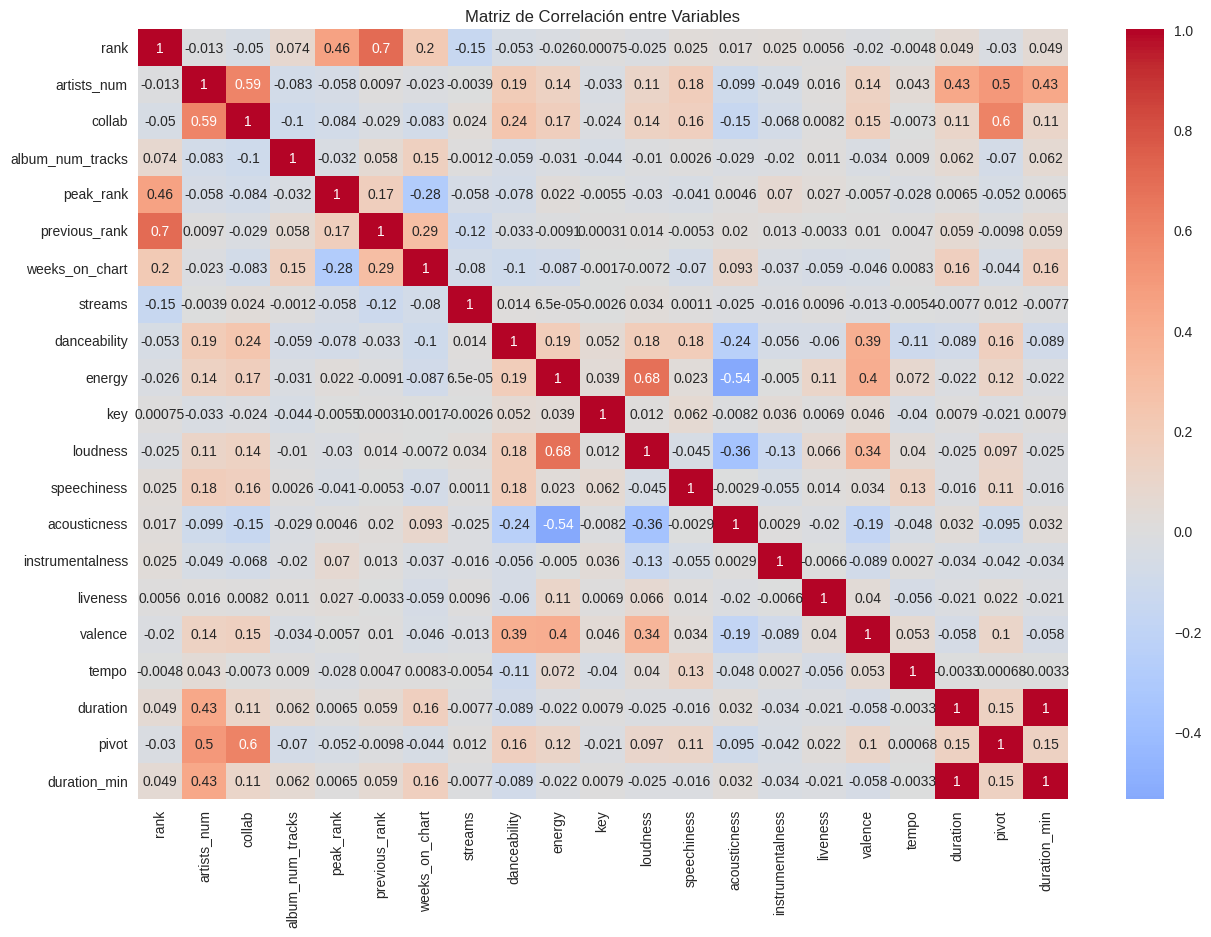

In [27]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación entre Variables')
plt.show()

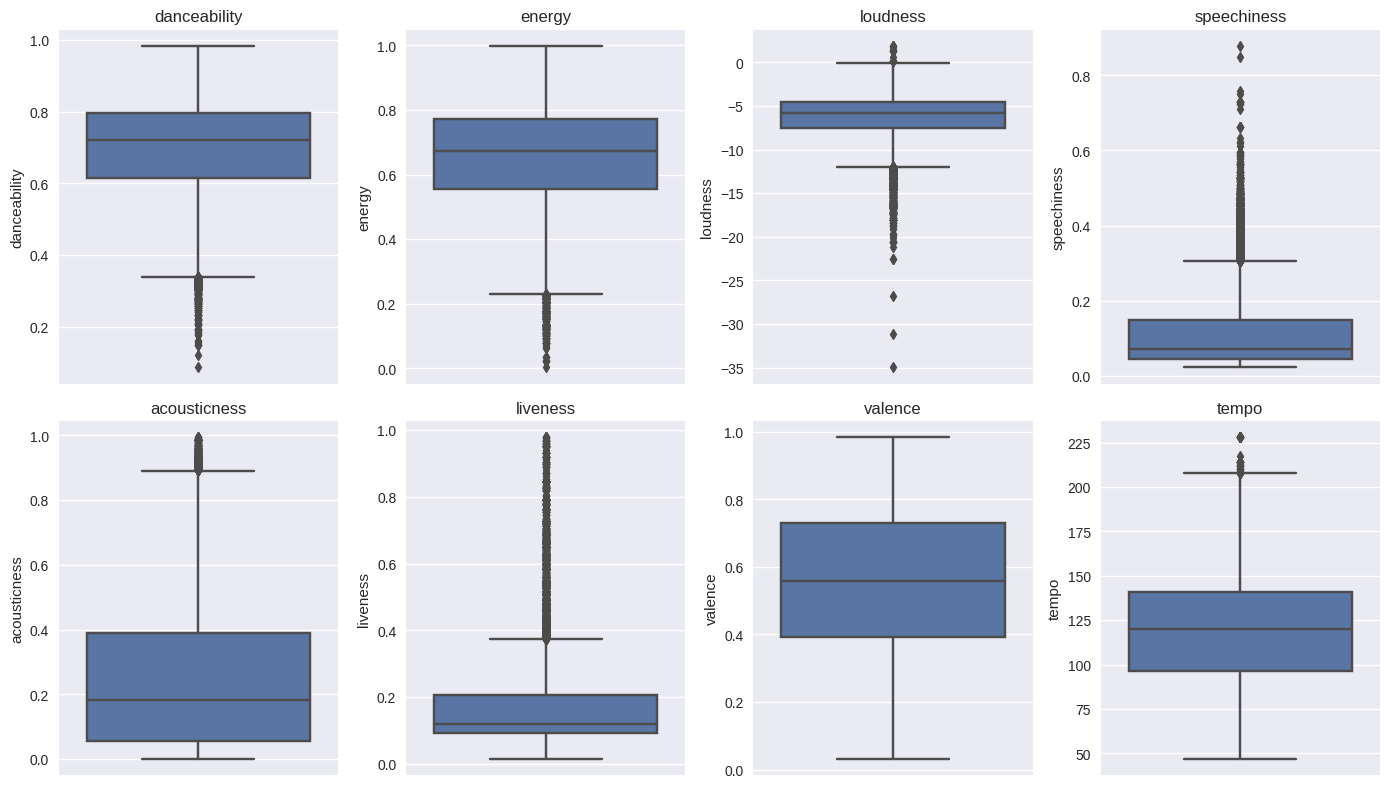

In [28]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                 'acousticness', 'liveness', 'valence', 'tempo']

plt.figure(figsize=(14, 8))
for i, feature in enumerate(audio_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(data=df, y=feature)
    plt.title(feature)
plt.tight_layout()
plt.show()

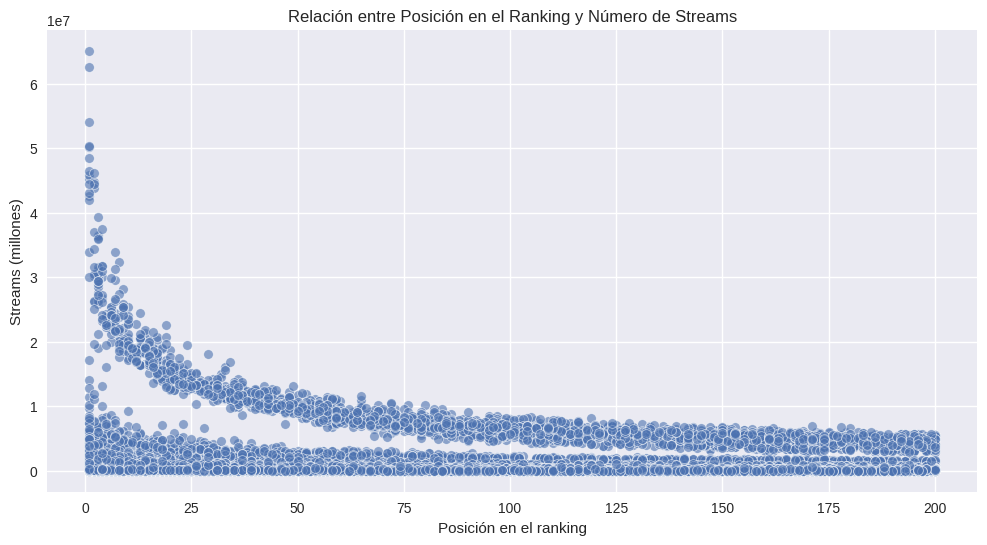

In [29]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='rank', y='streams', alpha=0.6)
plt.title('Relación entre Posición en el Ranking y Número de Streams')
plt.xlabel('Posición en el ranking')
plt.ylabel('Streams (millones)')
plt.gca()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


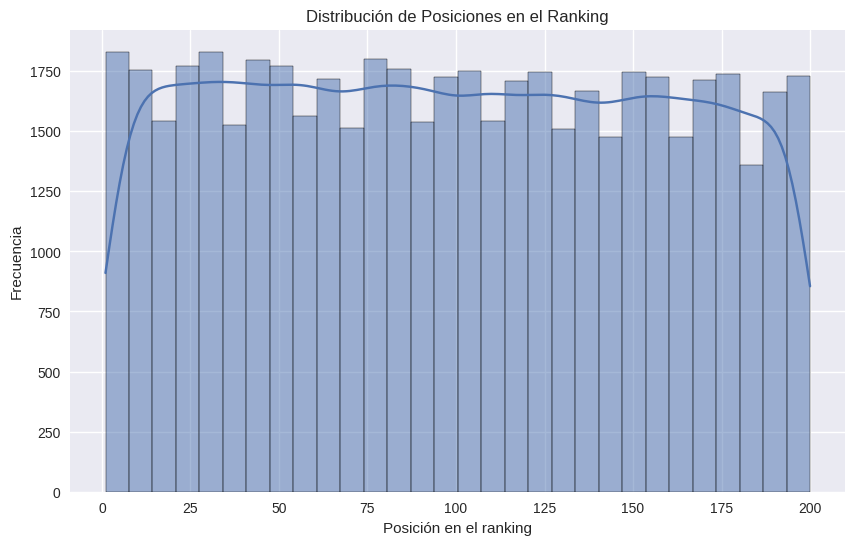

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='rank', bins=30, kde=True)
plt.title('Distribución de Posiciones en el Ranking')
plt.xlabel('Posición en el ranking')
plt.ylabel('Frecuencia')
plt.gca()  
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


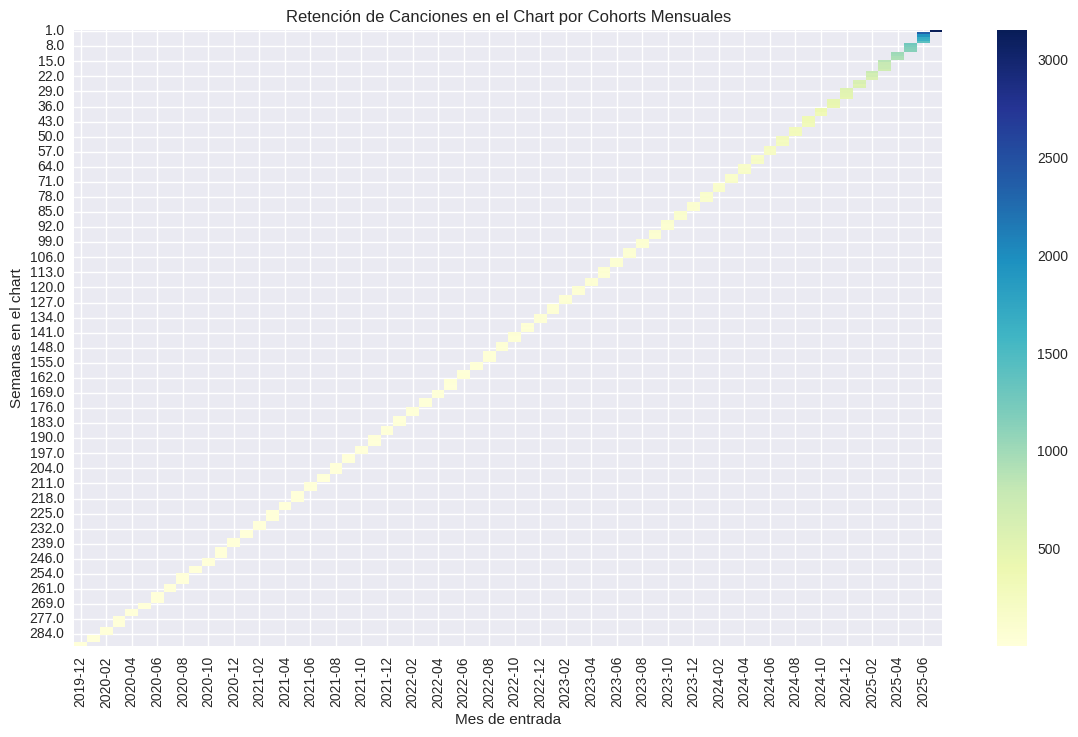

In [32]:

df['entry_date'] = pd.to_datetime('today') - pd.to_timedelta(df['weeks_on_chart'], unit='w')
df['entry_month'] = df['entry_date'].dt.to_period('M')

cohort_analysis = df.groupby(['entry_month', 'weeks_on_chart'])['rank'].count().unstack(0)
plt.figure(figsize=(14, 8))
sns.heatmap(cohort_analysis, cmap='YlGnBu', fmt='.0f')
plt.title('Retención de Canciones en el Chart por Cohorts Mensuales')
plt.ylabel('Semanas en el chart')
plt.xlabel('Mes de entrada')
plt.show()

In [37]:
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 
            'tempo', 'duration_min', 'streams', 'weeks_on_chart']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

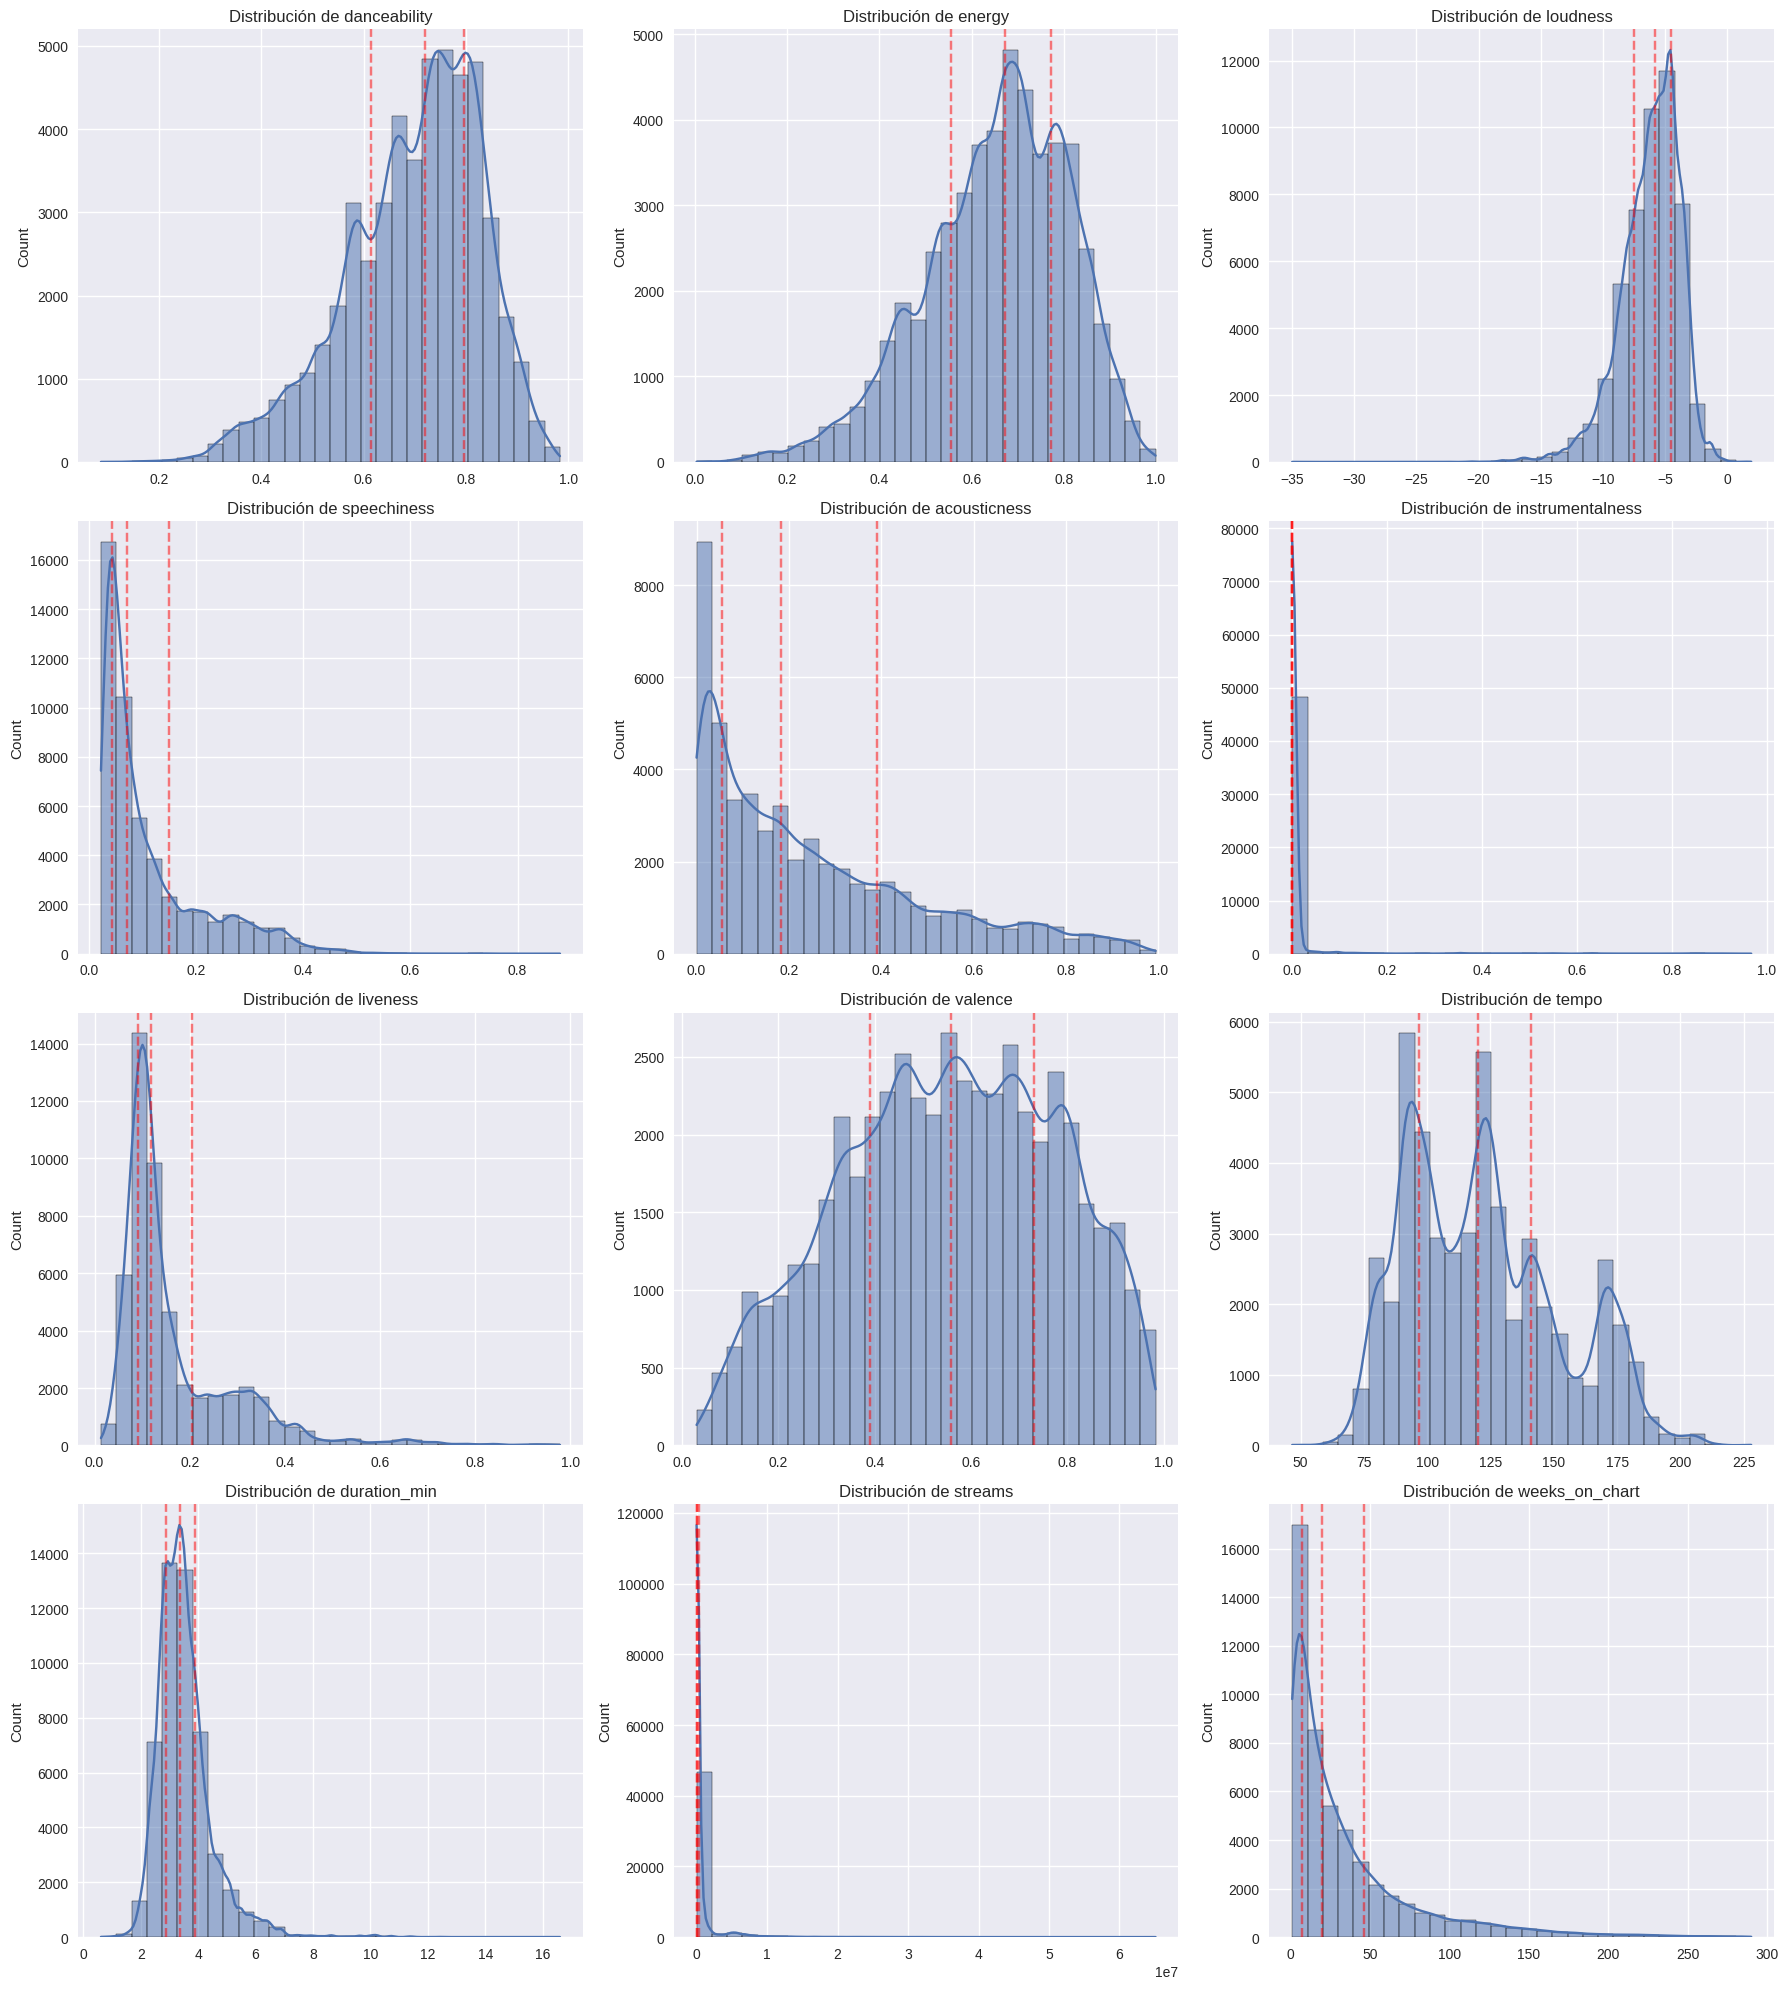

In [39]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'Distribución de {feature}', fontsize=12)
    axes[i].set_xlabel('')
    
    # percentiles
    for p in [25, 50, 75]:
        axes[i].axvline(df[feature].quantile(p/100), color='r', linestyle='--', alpha=0.5)
    
plt.tight_layout()
plt.show()

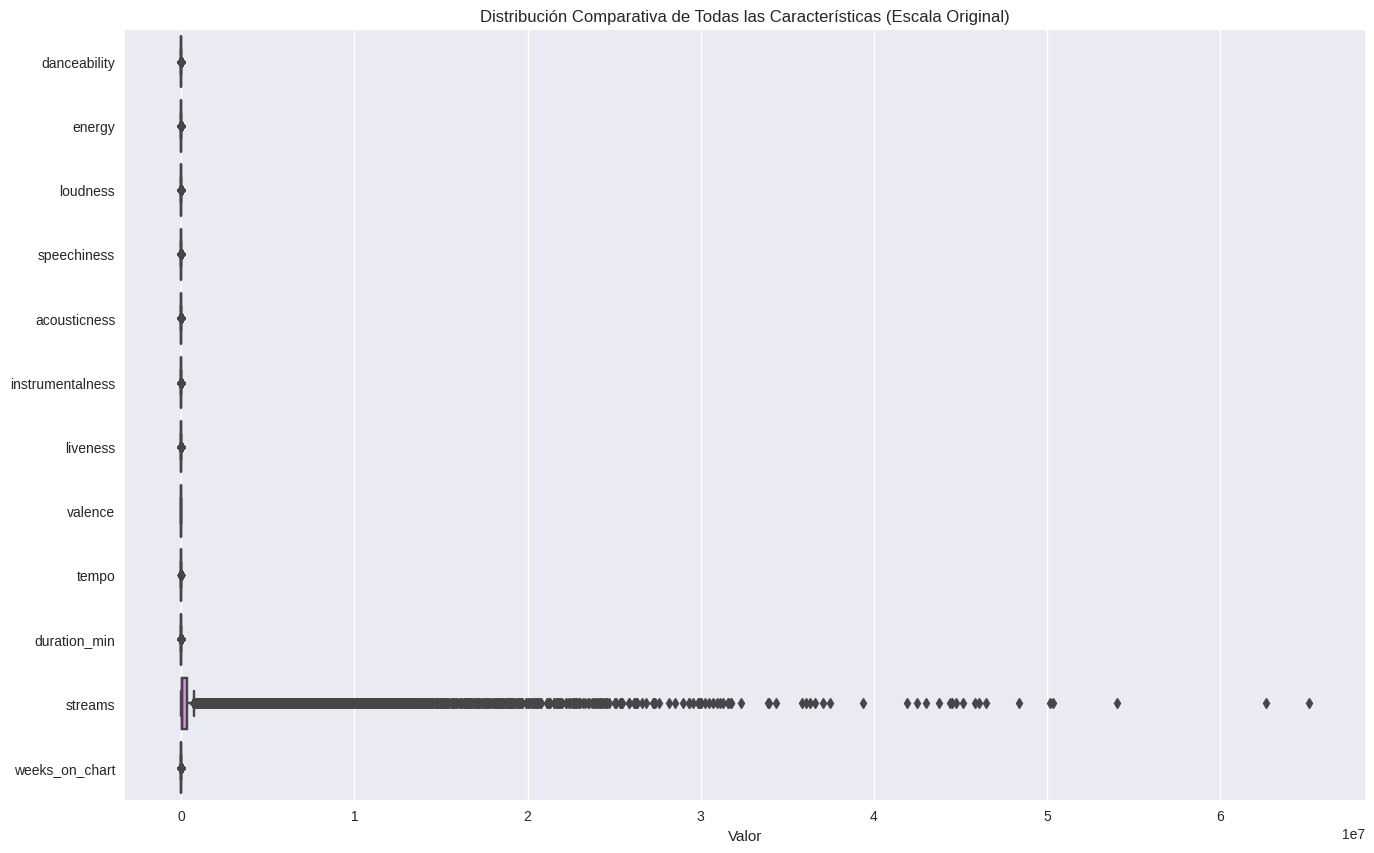

In [40]:
plt.figure(figsize=(16, 10))
sns.boxplot(data=df[features], orient='h', whis=1.5)
plt.title('Distribución Comparativa de Todas las Características (Escala Original)')
plt.xlabel('Valor')
plt.show()

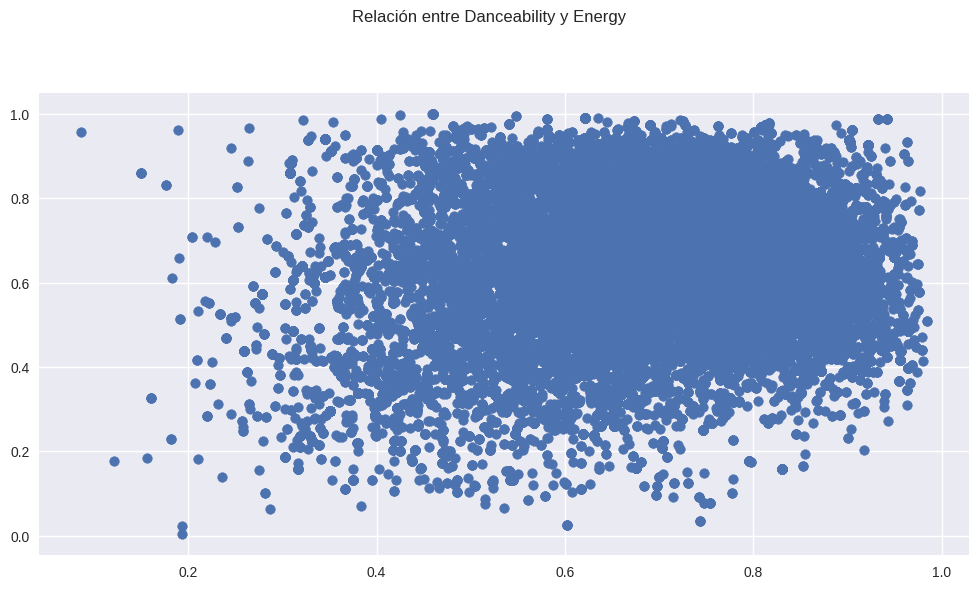

In [45]:
plt.scatter(data=df, x='danceability', y='energy')
plt.suptitle('Relación entre Danceability y Energy', y=1.02)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

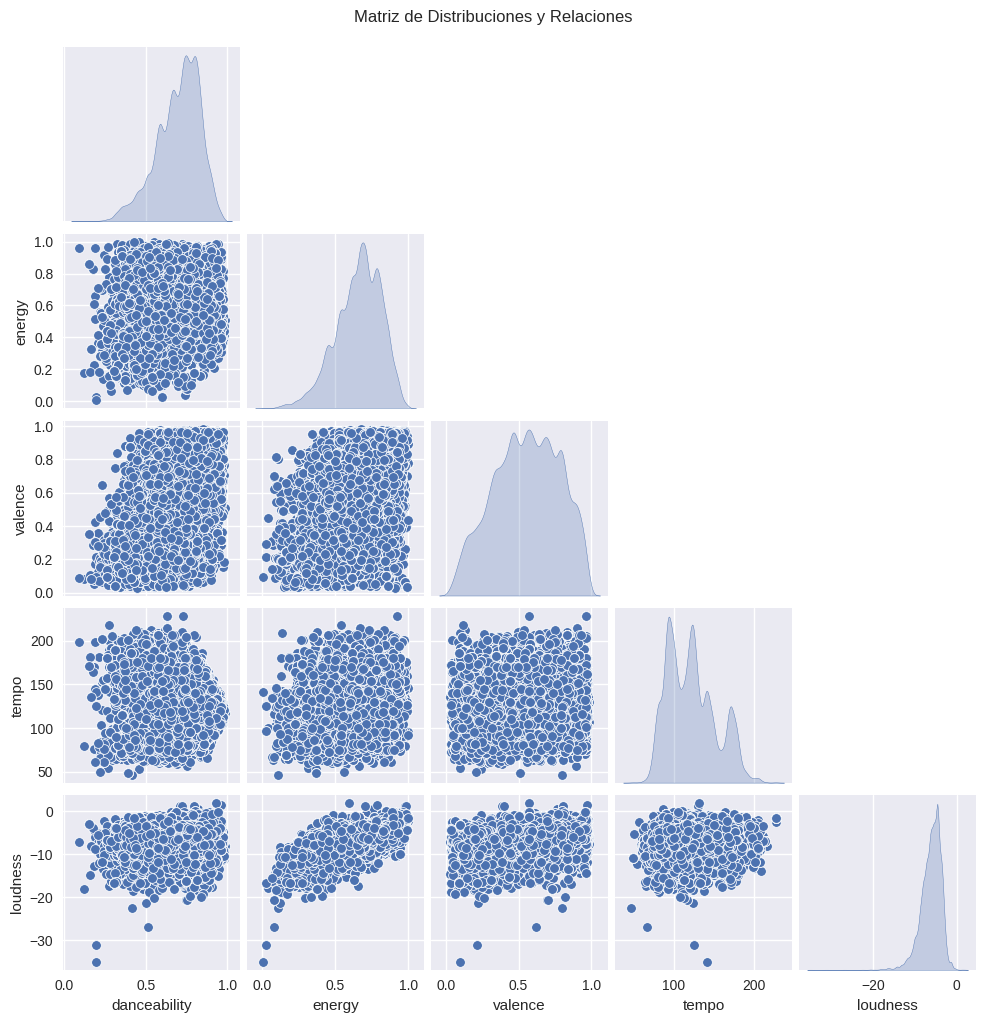

In [46]:
selected_features = ['danceability', 'energy', 'valence', 'tempo', 'loudness']
sns.pairplot(df[selected_features], diag_kind='kde', corner=True, height=2)
plt.suptitle('Matriz de Distribuciones y Relaciones', y=1.02)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

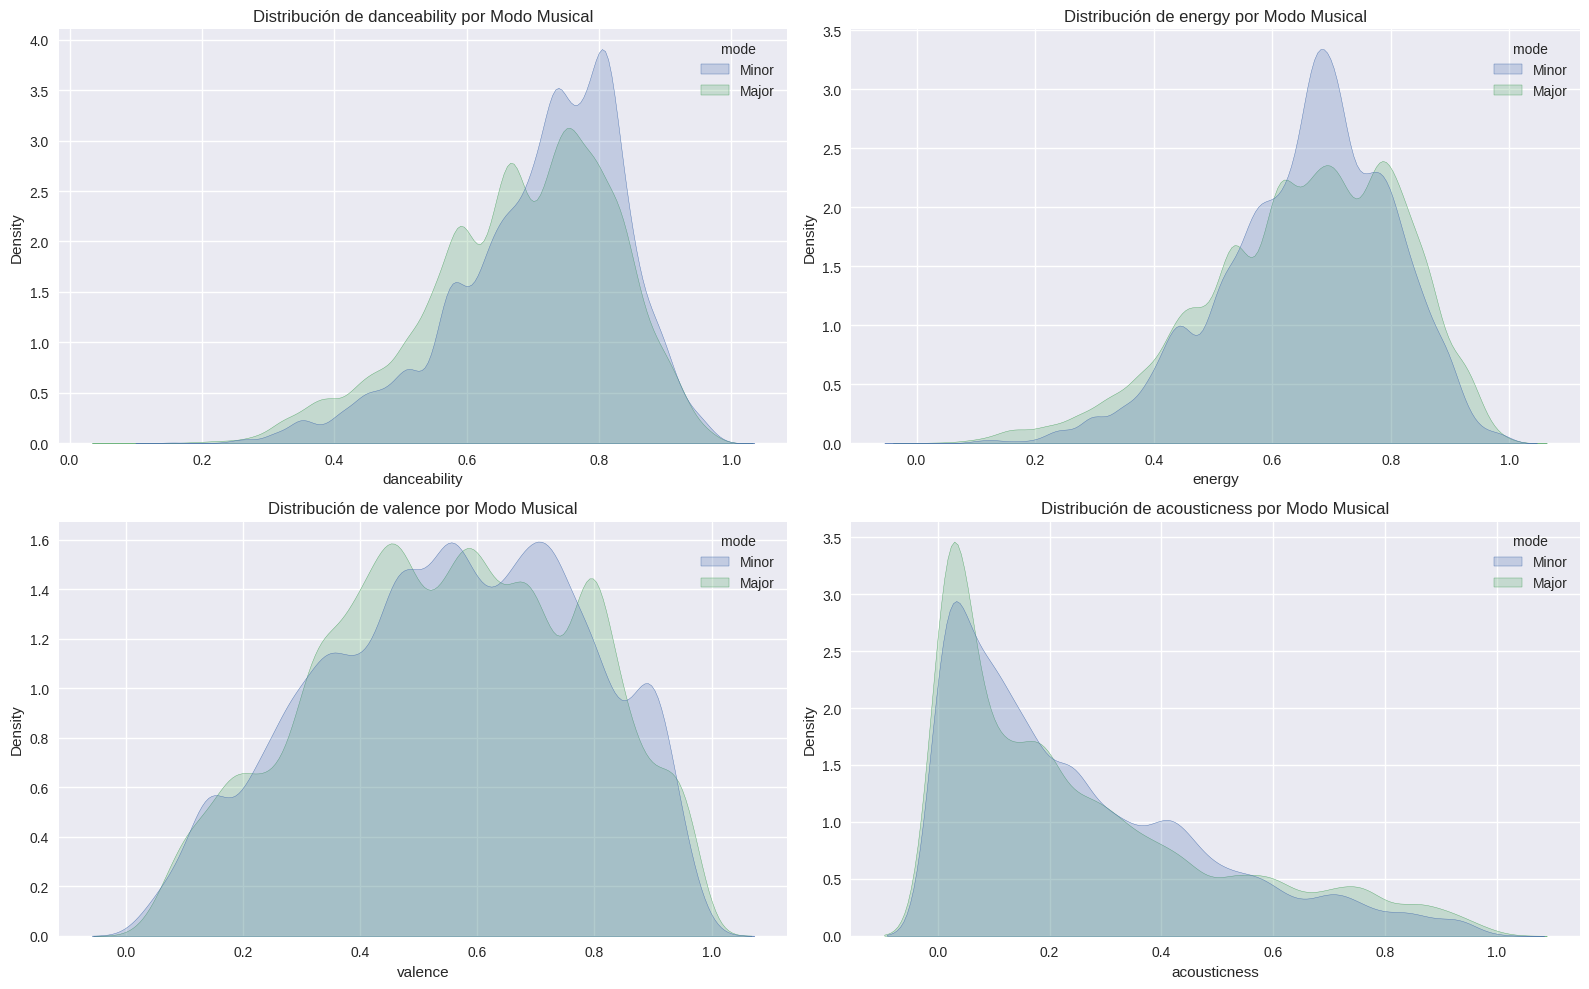

In [47]:
plt.figure(figsize=(16, 10))
for i, feature in enumerate(['danceability', 'energy', 'valence', 'acousticness'], 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=df, x=feature, hue='mode', fill=True, common_norm=False)
    plt.title(f'Distribución de {feature} por Modo Musical')
plt.tight_layout()
plt.show()

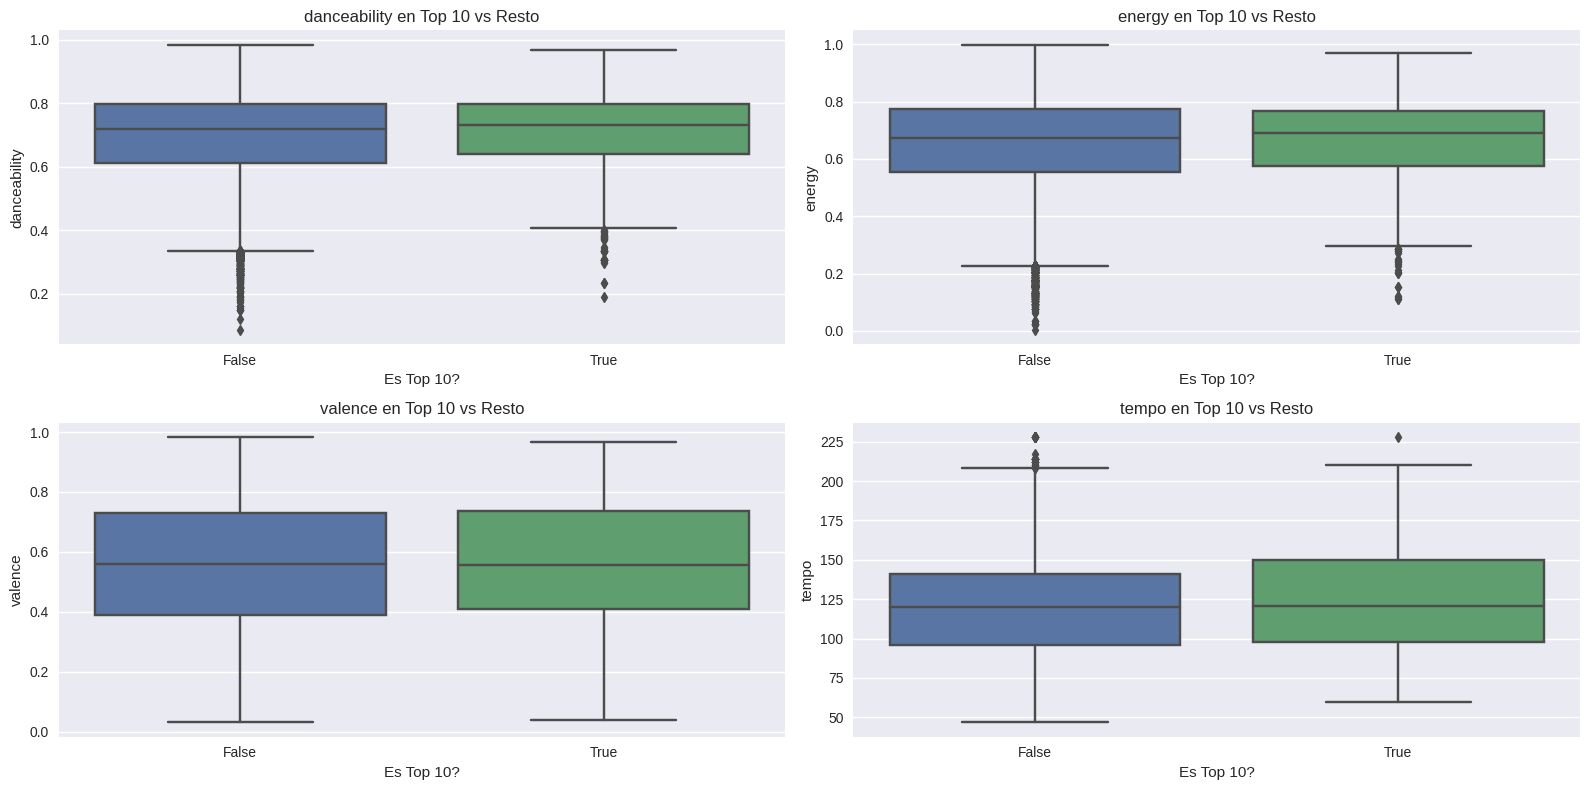

In [48]:
df['top_10'] = df['rank'] <= 10

plt.figure(figsize=(16, 8))
for i, feature in enumerate(['danceability', 'energy', 'valence', 'tempo'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='top_10', y=feature)
    plt.title(f'{feature} en Top 10 vs Resto')
    plt.xlabel('Es Top 10?')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


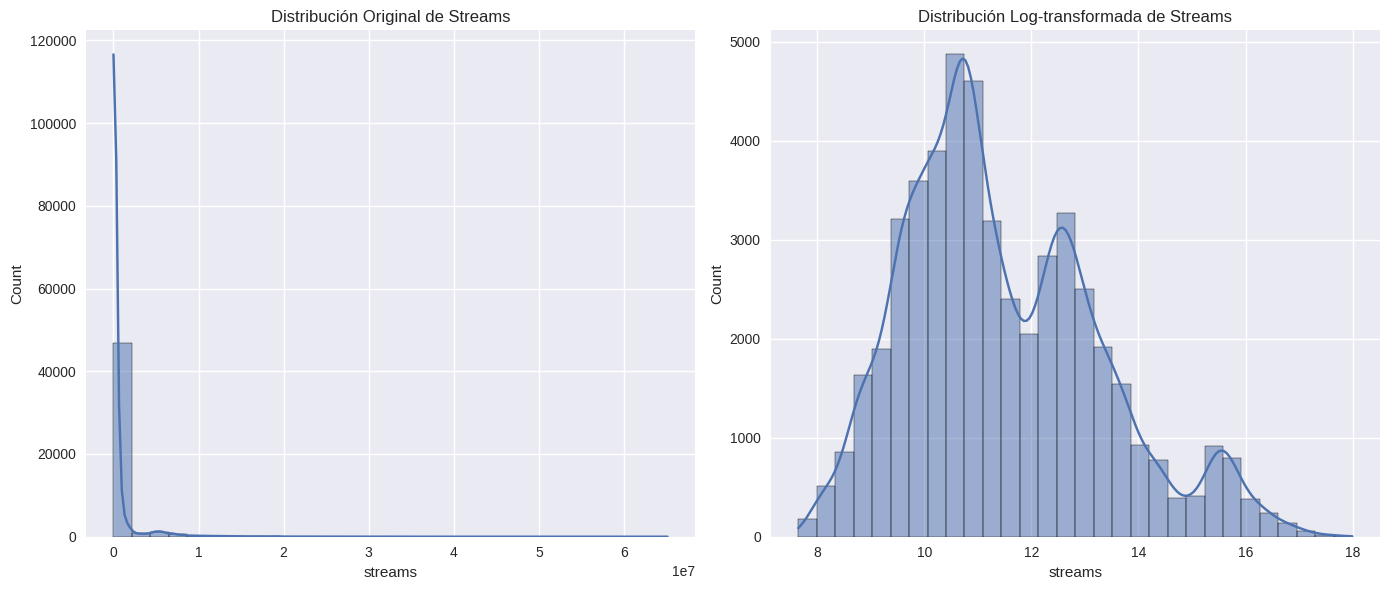

In [49]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['streams'], kde=True, bins=30)
plt.title('Distribución Original de Streams')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['streams']), kde=True, bins=30)
plt.title('Distribución Log-transformada de Streams')
plt.tight_layout()
plt.show()

Diferencias entre Top 20 y resto:

DANCEABILITY:
Top 20: Mediana = 0.73
Resto: Mediana = 0.72
Diferencia absoluta: 0.02
p-valor = 0.0000 ***

ENERGY:
Top 20: Mediana = 0.69
Resto: Mediana = 0.67
Diferencia absoluta: 0.02
p-valor = 0.0000 ***

VALENCE:
Top 20: Mediana = 0.57
Resto: Mediana = 0.56
Diferencia absoluta: 0.02
p-valor = 0.0001 ***

LOUDNESS:
Top 20: Mediana = -5.67
Resto: Mediana = -5.88
Diferencia absoluta: 0.21
p-valor = 0.0001 ***

TEMPO:
Top 20: Mediana = 119.98
Resto: Mediana = 119.93
Diferencia absoluta: 0.05
p-valor = 0.0001 ***

ACOUSTICNESS:
Top 20: Mediana = 0.19
Resto: Mediana = 0.18
Diferencia absoluta: 0.01
p-valor = 0.6619 ns

SPEECHINESS:
Top 20: Mediana = 0.08
Resto: Mediana = 0.07
Diferencia absoluta: 0.00
p-valor = 0.5038 ns


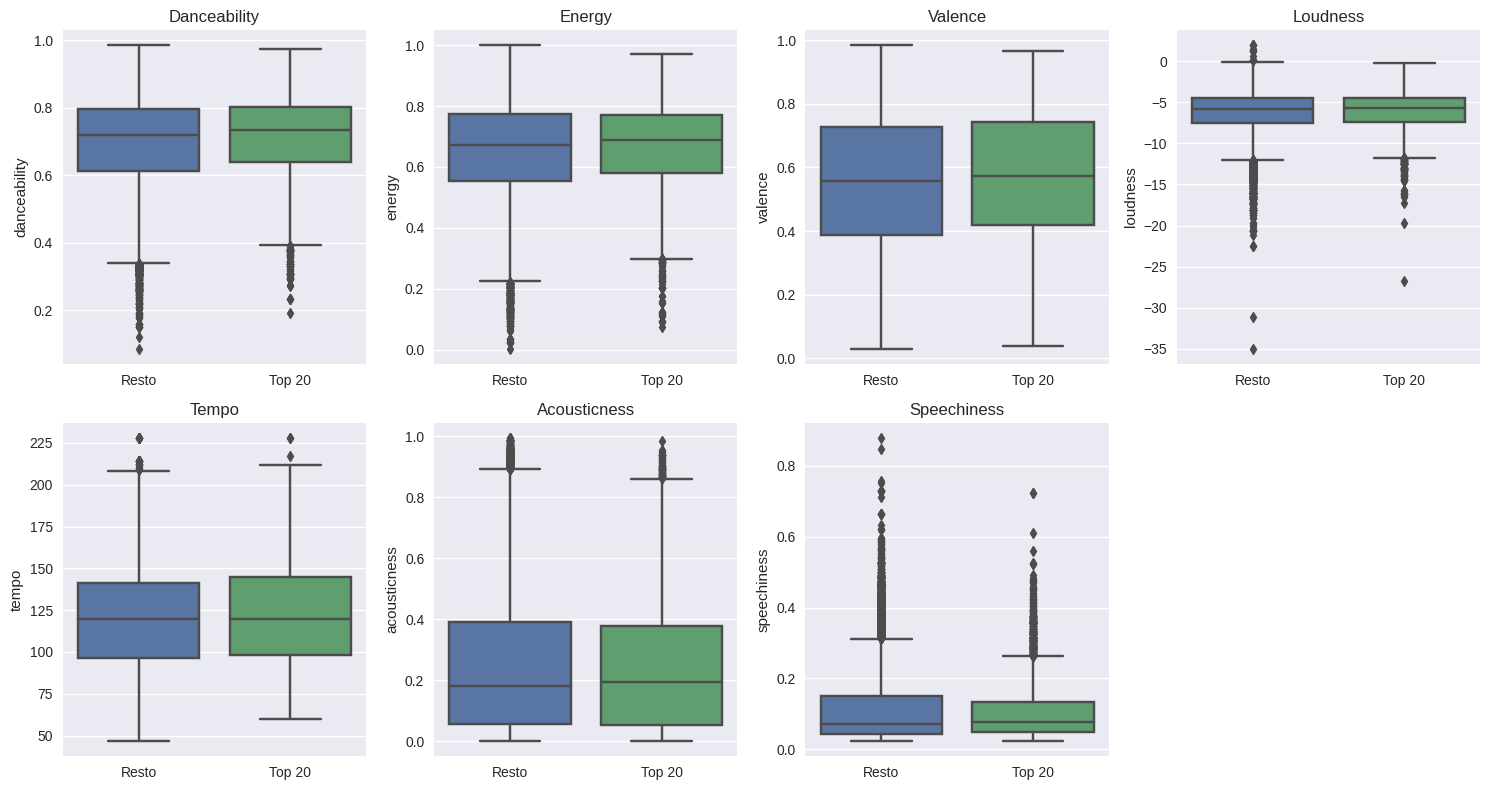

In [50]:
df['top_20'] = df['rank'] <= 20
top_20 = df[df['top_20']]
resto = df[~df['top_20']]

from scipy.stats import mannwhitneyu

features = ['danceability', 'energy', 'valence', 'loudness', 
            'tempo', 'acousticness', 'speechiness']

print("Diferencias entre Top 20 y resto:")
for feature in features:
    stat, p = mannwhitneyu(top_20[feature], resto[feature])
    print(f"\n{feature.upper()}:")
    print(f"Top 20: Mediana = {top_20[feature].median():.2f}")
    print(f"Resto: Mediana = {resto[feature].median():.2f}")
    print(f"Diferencia absoluta: {abs(top_20[feature].median() - resto[feature].median()):.2f}")
    print(f"p-valor = {p:.4f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'}")



plt.figure(figsize=(15, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x='top_20', y=feature, data=df)
    plt.title(feature.capitalize())
    plt.xlabel('')
    plt.xticks([0, 1], ['Resto', 'Top 20'])
plt.tight_layout()
plt.show()